# IPL Score Prediction using Stacked LSTM
Group G-3 | AKGEC

Pipeline: Data Loading -> Preprocessing -> EDA -> Sequence Building -> Stacked LSTM Training -> Testing -> Metrics -> Train/Test Comparison

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style('whitegrid')
%matplotlib inline

METRICS_DIR = 'training and testing metrices'
os.makedirs(METRICS_DIR, exist_ok=True)

## 2. Data Loading
Dataset: `patrickb1912/ipl-complete-dataset-20082020`. Place `matches.csv` and `deliveries.csv` in the same folder as this notebook.

In [2]:
DATA_DIR = '.'  # local folder containing matches.csv and deliveries.csv

matches = pd.read_csv(f'{DATA_DIR}/matches.csv')
deliveries = pd.read_csv(f'{DATA_DIR}/deliveries.csv')

print('matches:', matches.shape)
print('deliveries:', deliveries.shape)
matches.head()

matches: (1095, 20)
deliveries: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


## 3. Data Preprocessing

In [4]:
# Drop rows with missing critical fields
deliveries = deliveries.dropna(subset=['batting_team', 'bowling_team'])

# Keep only normal innings (1=1st batting, 2=2nd batting). Drop Super Over innings (3+).
deliveries = deliveries[deliveries['inning'].isin([1, 2])]

# Keep only teams that are still relevant / consistently named (optional cleanup)
consistent_teams = deliveries['batting_team'].value_counts()
consistent_teams = consistent_teams[consistent_teams > 500].index.tolist()
deliveries = deliveries[deliveries['batting_team'].isin(consistent_teams) & deliveries['bowling_team'].isin(consistent_teams)]

# Merge venue from matches
deliveries = deliveries.merge(matches[['id', 'venue']], left_on='match_id', right_on='id', how='left')

# Ball-level cumulative features per innings
deliveries = deliveries.sort_values(['match_id', 'inning', 'over', 'ball'])
deliveries['is_wicket'] = deliveries['is_wicket'].fillna(0).astype(int)

deliveries['cum_runs'] = deliveries.groupby(['match_id', 'inning'])['total_runs'].cumsum()
deliveries['cum_wickets'] = deliveries.groupby(['match_id', 'inning'])['is_wicket'].cumsum()

# True over number comes straight from the 'over' column (0-19). Do NOT recompute
# from row count -- deliveries.csv has one row per delivery INCLUDING wides/no-balls,
# so counting rows drifts away from the real over as extras pile up.
deliveries['current_over'] = deliveries['over'] + 1  # 1-20

# Legal balls bowled (wides/no-balls don't count as a legal delivery) -> used for run rate
is_extra_ball = deliveries['extras_type'].isin(['wides', 'noballs'])
deliveries['legal_ball'] = (~is_extra_ball).astype(int)
deliveries['balls_bowled'] = deliveries.groupby(['match_id', 'inning'])['legal_ball'].cumsum()
deliveries['current_run_rate'] = deliveries['cum_runs'] / deliveries['balls_bowled'].replace(0, np.nan) * 6
deliveries['current_run_rate'] = deliveries['current_run_rate'].fillna(0)

# Final score per innings (label)
final_scores = deliveries.groupby(['match_id', 'inning'])['total_runs'].sum().reset_index()
final_scores.columns = ['match_id', 'inning', 'final_score']
deliveries = deliveries.merge(final_scores, on=['match_id', 'inning'], how='left')

deliveries[['match_id','inning','current_over','cum_runs','cum_wickets','current_run_rate','final_score']].head()

,match_id,inning,current_over,cum_runs,cum_wickets,current_run_rate,final_score
0,335982,1,1,1,0,6.0,222
1,335982,1,1,1,0,3.0,222
2,335982,1,1,2,0,6.0,222
3,335982,1,1,2,0,4.0,222
4,335982,1,1,2,0,3.0,222


In [5]:
# Encode categorical columns
le_team = LabelEncoder()
le_venue = LabelEncoder()

all_teams = pd.concat([deliveries['batting_team'], deliveries['bowling_team']]).unique()
le_team.fit(all_teams)

deliveries['venue'] = deliveries['venue'].fillna('Unknown')
le_venue.fit(deliveries['venue'])

deliveries['batting_team_enc'] = le_team.transform(deliveries['batting_team'])
deliveries['bowling_team_enc'] = le_team.transform(deliveries['bowling_team'])
deliveries['venue_enc'] = le_venue.transform(deliveries['venue'])

## 4. Exploratory Data Analysis (EDA)

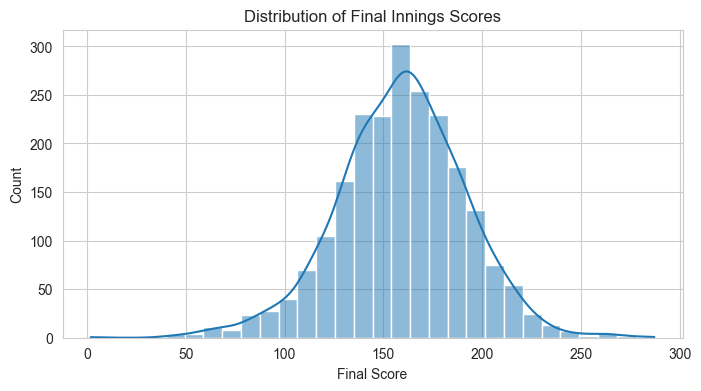

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(final_scores['final_score'], bins=30, kde=True)
plt.title('Distribution of Final Innings Scores')
plt.xlabel('Final Score')
plt.show()

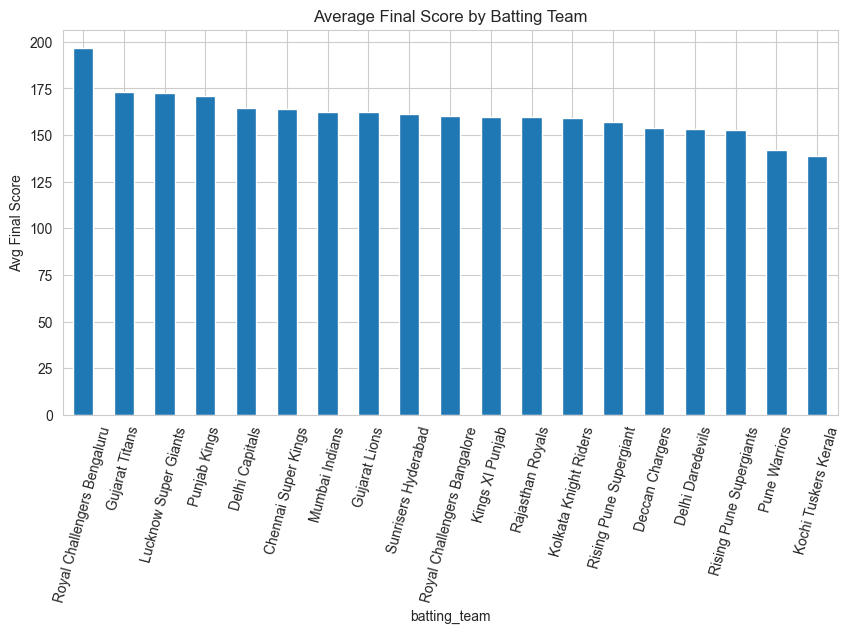

In [7]:
avg_by_team = deliveries.groupby('batting_team')['final_score'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
avg_by_team.plot(kind='bar')
plt.title('Average Final Score by Batting Team')
plt.ylabel('Avg Final Score')
plt.xticks(rotation=75)
plt.show()

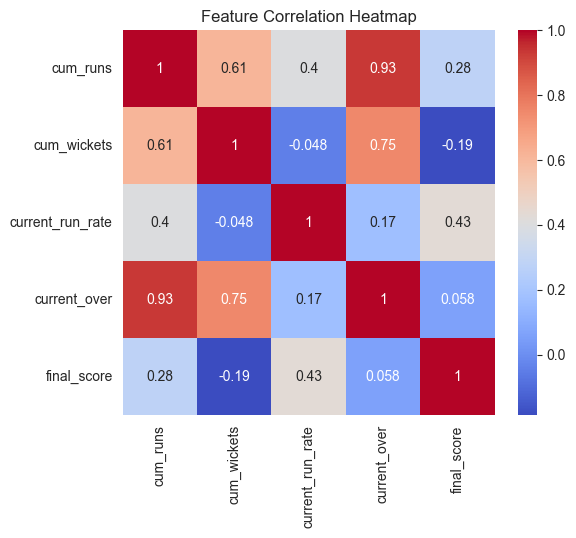

In [8]:
corr_cols = ['cum_runs', 'cum_wickets', 'current_run_rate', 'current_over', 'final_score']
plt.figure(figsize=(6,5))
sns.heatmap(deliveries[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## 5. Sequence Building (per innings, over-by-over)

In [9]:
FEATURES = ['cum_runs', 'cum_wickets', 'current_run_rate', 'current_over',
            'batting_team_enc', 'bowling_team_enc', 'venue_enc']
MAX_OVERS = 20

# One row per (match, inning, over) snapshot -> last ball of each over
over_snapshots = deliveries.groupby(['match_id', 'inning', 'current_over']).last().reset_index()

sequences = []
labels = []
groups = []

for (match_id, inning), grp in over_snapshots.groupby(['match_id', 'inning']):
    grp = grp.sort_values('current_over')
    seq = grp[FEATURES].values
    label = grp['final_score'].iloc[0]
    sequences.append(seq)
    labels.append(label)
    groups.append(match_id)

X = pad_sequences(sequences, maxlen=MAX_OVERS, dtype='float32', padding='post', truncating='post')
y = np.array(labels, dtype='float32')
groups = np.array(groups)

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (2187, 20, 7)
y shape: (2187,)


In [10]:
# Scale features (fit scaler on flattened non-padded values)
n_samples, n_timesteps, n_features = X.shape
scaler = MinMaxScaler()
X_reshaped = X.reshape(-1, n_features)
X_scaled = scaler.fit_transform(X_reshaped).reshape(n_samples, n_timesteps, n_features)

## 6. Train / Test Split
Split by match id so no innings from the same match leaks across sets.

In [11]:
unique_matches = np.unique(groups)
train_matches, test_matches = train_test_split(unique_matches, test_size=0.2, random_state=SEED)

train_idx = np.isin(groups, train_matches)
test_idx = np.isin(groups, test_matches)

X_train, y_train = X_scaled[train_idx], y[train_idx]
X_test, y_test = X_scaled[test_idx], y[test_idx]

# Scale the target too. With an unscaled target (0-280 runs) the Dense(1, linear) output
# layer has to learn a large output scale from scratch, which makes the LSTM converge very
# slowly / get stuck near the mean. Scaling to roughly [0,1] fixes this.
Y_SCALE = 300.0
y_train_scaled = y_train / Y_SCALE
y_test_scaled = y_test / Y_SCALE

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (1749, 20, 7) Test: (438, 20, 7)


## 7. Model: Stacked LSTM

In [12]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(MAX_OVERS, n_features)),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='huber', metrics=['mae'])
model.summary()

C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,153 (473.25 KB)

 Trainable params: 121,153 (473.25 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Training Pipeline

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

history = model.fit(
    X_train, y_train_scaled,
    validation_split=0.15,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150


 1/47 ━━━━━━━━━━━━━━━━━━━━ 9:02 12s/step - loss: 0.1237 - mae: 0.4850

 2/47 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.1091 - mae: 0.4479 

 3/47 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0964 - mae: 0.4102

 4/47 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0866 - mae: 0.3798

...

42/47 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.1787e-04 - mae: 0.0116

44/47 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.1786e-04 - mae: 0.0116

45/47 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.1785e-04 - mae: 0.0116

46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.1782e-04 - mae: 0.0116

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 1.1777e-04 - mae: 0.0116 - val_loss: 5.6780e-05 - val_mae: 0.0076


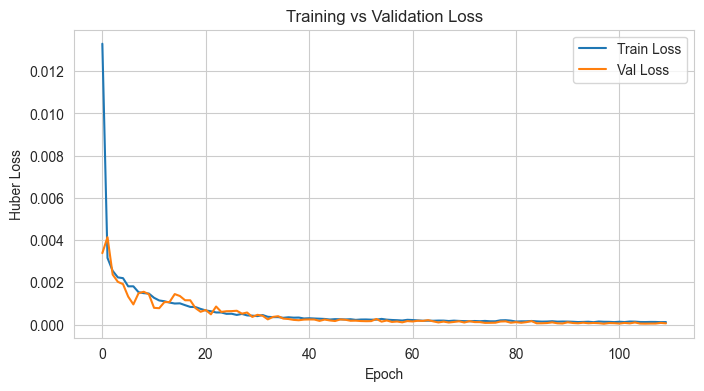

In [14]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.legend()
plt.savefig(os.path.join(METRICS_DIR, 'training_vs_validation_loss.png'), dpi=200, bbox_inches='tight')
plt.show()

## 9. Testing Pipeline

In [15]:
# Predictions come out scaled (roughly 0-1) -- rescale back to actual runs
y_train_pred = model.predict(X_train).flatten() * Y_SCALE
y_test_pred = model.predict(X_test).flatten() * Y_SCALE

 1/55 ━━━━━━━━━━━━━━━━━━━━ 50s 933ms/step

 3/55 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step  

 6/55 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

 8/55 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step

12/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

...

 6/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

 8/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

10/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


## 10. Metrics
This is a regression task, so we report regression metrics only: MAE, RMSE, R2.

In [16]:
def regression_metrics(y_true, y_pred, label=''):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'--- {label} ---')
    print(f'MAE  : {mae:.2f}')
    print(f'RMSE : {rmse:.2f}')
    print(f'R2   : {r2:.3f}')
    return mae, rmse, r2

train_mae, train_rmse, train_r2 = regression_metrics(y_train, y_train_pred, 'Train')
test_mae, test_rmse, test_r2 = regression_metrics(y_test, y_test_pred, 'Test')

--- Train ---
MAE  : 1.96
RMSE : 2.56
R2   : 0.994
--- Test ---
MAE  : 1.98
RMSE : 2.64
R2   : 0.993


## 11. Train vs Test Comparison

In [17]:
comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Train': [train_mae, train_rmse, train_r2],
    'Test': [test_mae, test_rmse, test_r2]
})

comparison.to_csv(os.path.join(METRICS_DIR, 'metrics_comparison.csv'), index=False)
with open(os.path.join(METRICS_DIR, 'metrics_comparison.txt'), 'w') as f:
    f.write(comparison.to_string(index=False))

comparison

,Metric,Train,Test
0,MAE,1.963065,1.981170
1,RMSE,2.558967,2.639565
2,R2,0.993919,0.992961


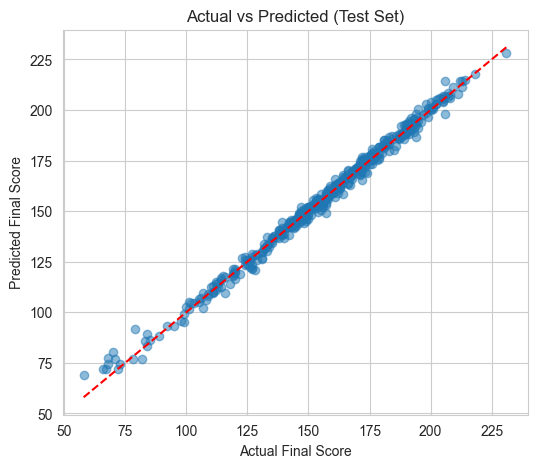

In [18]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.title('Actual vs Predicted (Test Set)')
plt.savefig(os.path.join(METRICS_DIR, 'actual_vs_predicted.png'), dpi=200, bbox_inches='tight')
plt.show()

## 12. Save Model + Preprocessing Objects (for Flask deployment)

In [19]:
import pickle

model.save('ipl_lstm_model.keras')

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('le_team.pkl', 'wb') as f:
    pickle.dump(le_team, f)
with open('le_venue.pkl', 'wb') as f:
    pickle.dump(le_venue, f)
with open('y_scale.pkl', 'wb') as f:
    pickle.dump(Y_SCALE, f)

print('Saved: ipl_lstm_model.keras, scaler.pkl, le_team.pkl, le_venue.pkl, y_scale.pkl')

Saved: ipl_lstm_model.keras, scaler.pkl, le_team.pkl, le_venue.pkl, y_scale.pkl
